In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,1640.0,NaN,NaN,0,0,0,1,0,0,67
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,2690.0,2599.0,2450.0,1,1,0,0,0,0,174
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,NaN,2937.0,1762.0,0,0,0,0,0,0,0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,1850.0,NaN,NaN,1,0,0,0,0,0,0
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,1578.0,NaN,NaN,0,0,0,1,0,2,94


In [4]:
df.shape

(3803, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_name        3803 non-null   object 
 1   property_type        3803 non-null   object 
 2   society              3802 non-null   object 
 3   sector               3803 non-null   object 
 4   price                3785 non-null   float64
 5   price_per_sqft       3785 non-null   float64
 6   area                 3785 non-null   float64
 7   areaWithType         3803 non-null   object 
 8   bedRoom              3803 non-null   int64  
 9   bathroom             3803 non-null   int64  
 10  balcony              3803 non-null   object 
 11  address              3794 non-null   object 
 12  floorNum             3784 non-null   float64
 13  facing               2698 non-null   object 
 14  agePossession        3803 non-null   object 
 15  description          3803 non-null   o

In [7]:
df.duplicated().sum()

np.int64(4)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(3799, 27)

# 1.property_type        

<Axes: xlabel='property_type'>

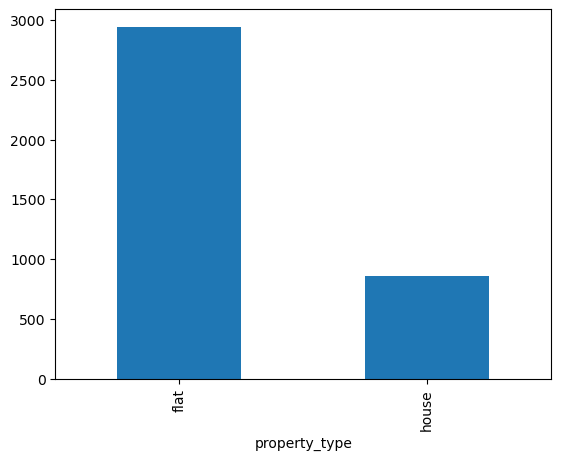

In [11]:
df['property_type'].value_counts().plot(kind='bar')

## Observations
- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

# 2.society

In [12]:
df['society'].value_counts().shape

(676,)

In [13]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              74
shapoorji pallonji joyville gurugram     45
dlf new town heights                     42
                                       ... 
the roselia 2                             1
new sathi apartments                      1
raheja the vedaanta floors                1
rail vihar cghs                           1
chintamani                                1
Name: count, Length: 676, dtype: int64

In [14]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.022645
ss the leaf                             0.044988
shapoorji pallonji joyville gurugram    0.058575
dlf new town heights                    0.071256
signature global park                   0.082428
                                          ...   
ireo skyon                              0.485507
bestech park view ananda                0.489734
ireo the corridors                      0.493659
ats kocoon                              0.497585
puri emerald bay                        0.501510
Name: proportion, Length: 75, dtype: float64

In [15]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(97),
 'Low (2-9)': np.int64(285),
 'Very Low (1)': np.int64(291)}

<Axes: xlabel='society'>

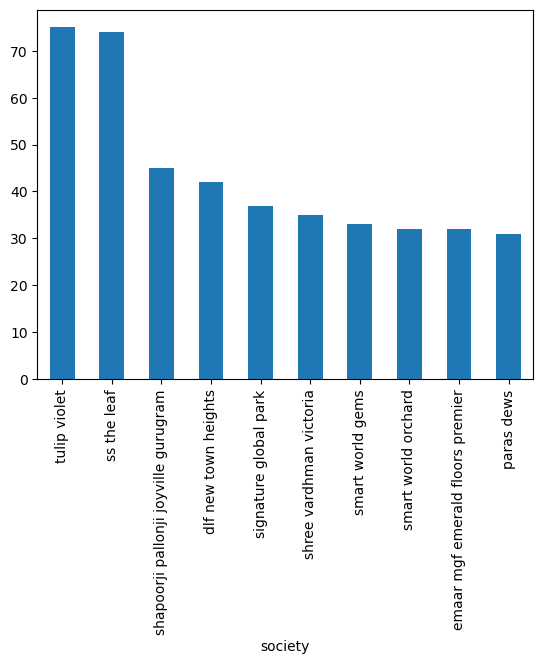

In [16]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [17]:
df['society'].isnull().sum()

np.int64(1)

In [18]:
df[df['society'].isnull()]

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2002,2 BHK Flat in Sector 78 Gurgaon,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


## Observations
- Around 13% properties comes under independent tag.
- There are 676 societies.
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
- Very High (>100): Only 1 society has more than 100 listings.
- High (50-100): 2 societies have between 50 to 100 listings.
- Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
- Low (2-9): 273 societies have between 2 to 9 listings.
- Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

# 3.sector

In [19]:
# unique sectors
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

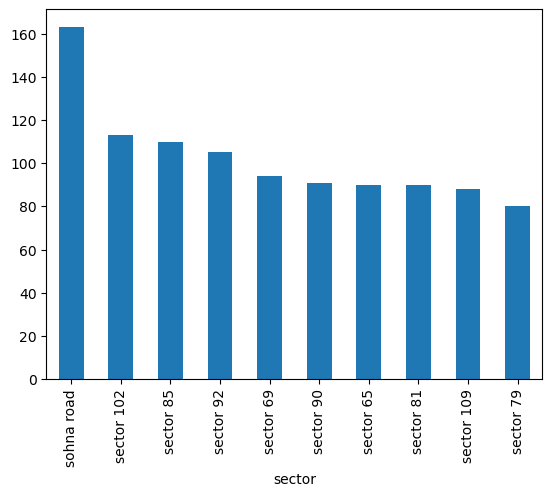

In [20]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [23]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(4),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(21),
 'Very Low (1)': np.int64(1)}

# Observations
- There are a total of 113 unique sectors in the dataset.
- Frequency distribution of sectors:
  - Very High (>100): 3 sectors have more than 100 listings.
  - High (50-100): 25 sectors have between 50 to 100 listings.
  - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
  - Low (2-9): 16 sectors have between 2 to 9 listings.
  - Very Low (1): Interestingly, there are no sectors with only 1 listing.

# 4.price

In [24]:
df['price'].isnull().sum()

np.int64(18)

In [25]:
df['price'].describe()

count    3781.000000
mean        2.506178
std         2.951625
min         0.070000
25%         0.940000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

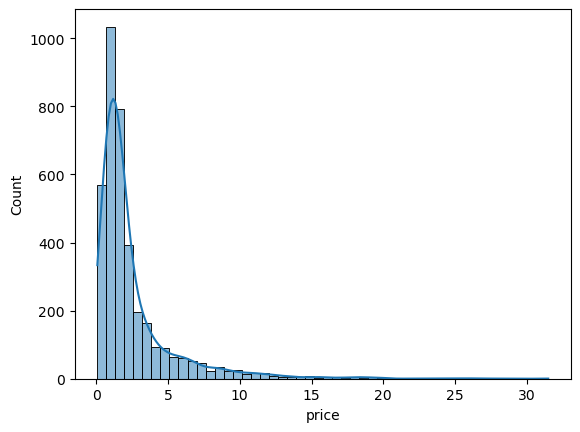

In [26]:
sns.histplot(df['price'], kde=True, bins=50)

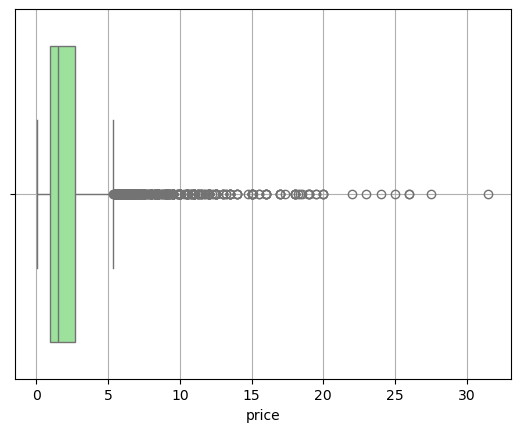

In [27]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

# Descriptive Statistics:

- Count: There are 3,781 non-missing price entries.
- Mean Price: The average price is approximately 2.50 crores.
- Median Price: The median (or 50th percentile) price is 1.50 crores.
- Standard Deviation: The prices have a standard deviation of 2.95, indicating variability in the prices.
- Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
- IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.94 crores to 2.70 crores.
    
# Visualizations:

  - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
  - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
- Missing Values: There are 17 missing values in the price column.

In [28]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.3094119777196798 15.23827310350981


- **Skewness**: The price distribution has a skewness of approximately 3.30, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

- **Kurtosis**: The kurtosis value is approximately 15.23. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.



In [29]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.25
0.05     0.37
0.95     8.49
0.99    15.02
Name: price, dtype: float64

# Quantile Analysis:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [30]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.7600000000000002)

In [31]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7000000000000006 5.340000000000001


In [32]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(432, 27)

In [33]:
outliers['price'].describe()

count    432.000000
mean       9.196157
std        4.061291
min        5.350000
25%        6.400000
50%        8.000000
75%       10.607500
max       31.500000
Name: price, dtype: float64

# Outliers Analysis (using IQR method):

- Based on the IQR method, there are 432 properties considered as outliers.
- These outliers have an average price of approximately 9.19 crores.
- The range for these outliers is from 5.35 crores to 31.5 crores.

<Axes: xlabel='price'>

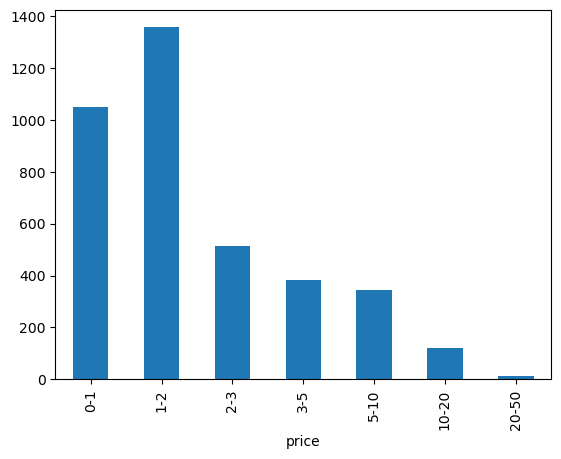

In [35]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

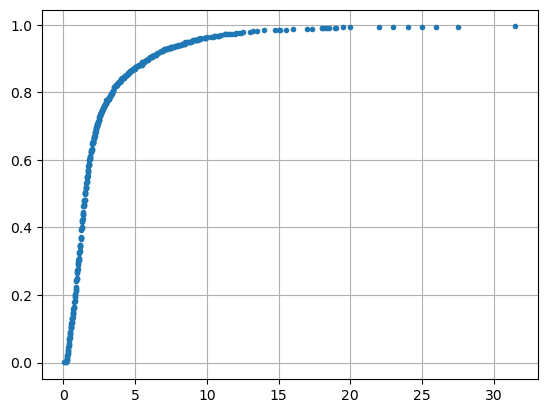

In [36]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

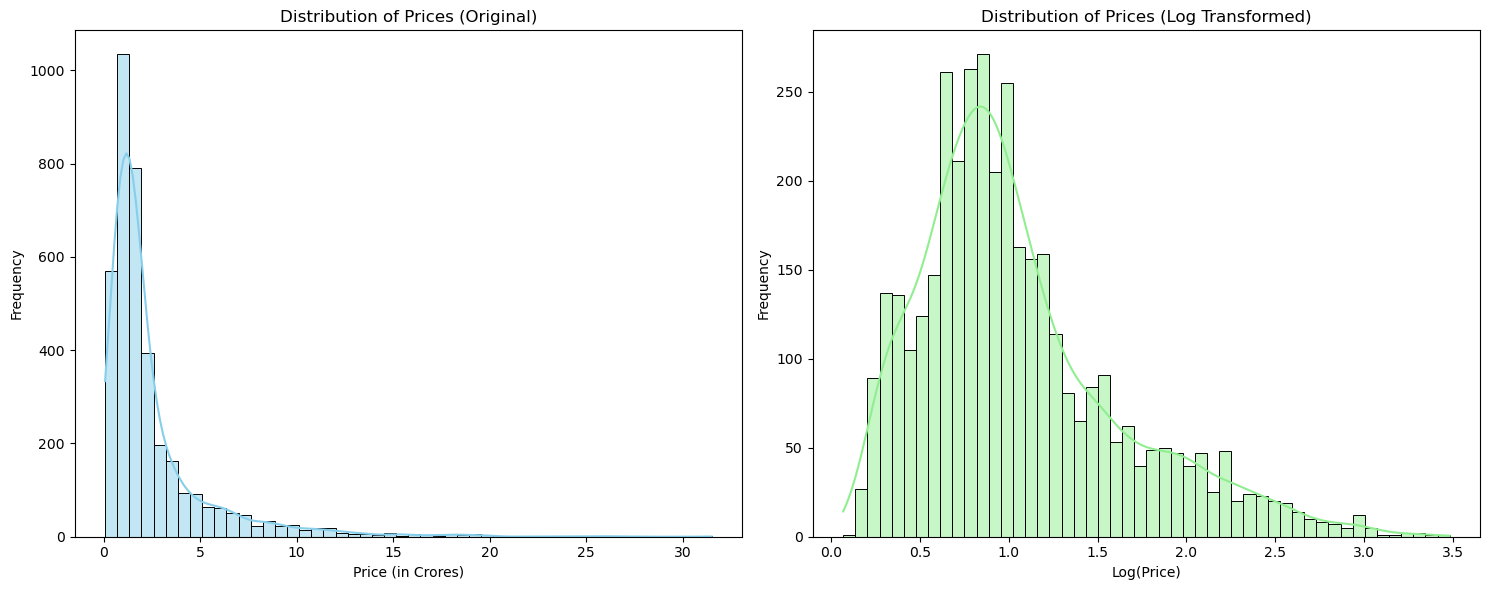

In [37]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

- np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

- Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [38]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0830646794509369 1.0038170768832715


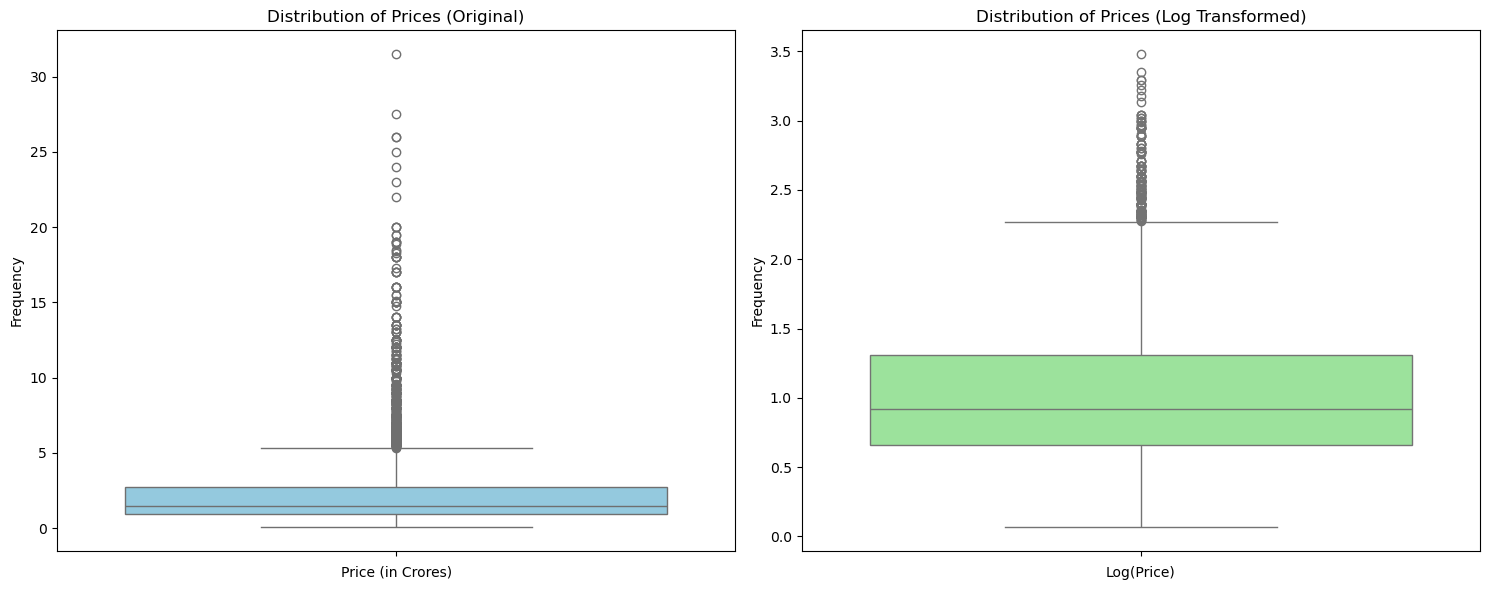

In [39]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 5.price_per_sqft

In [40]:
df['price_per_sqft'].isnull().sum()

np.int64(18)

In [41]:
df['price_per_sqft'].describe()

count      3781.000000
mean      13797.537953
std       23063.830898
min           4.000000
25%        6806.000000
50%        9000.000000
75%       13750.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

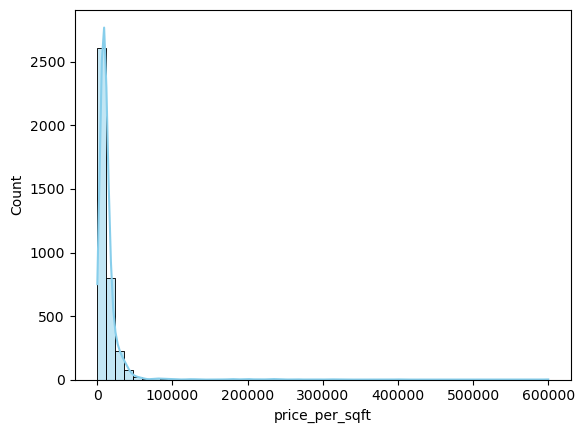

In [42]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

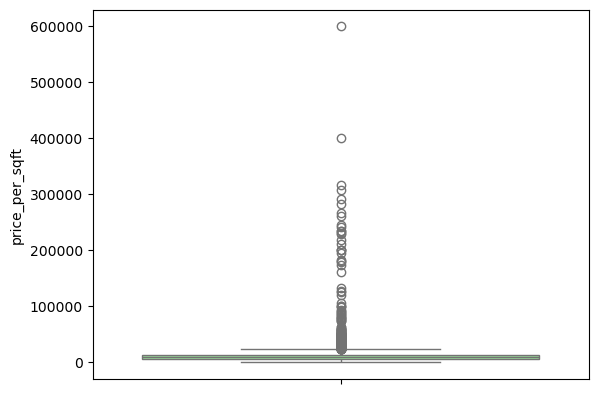

In [43]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

# Observations
- Potential Outliers
- Right Skewed
- 18 missing values

# 6.bedRoom

In [45]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

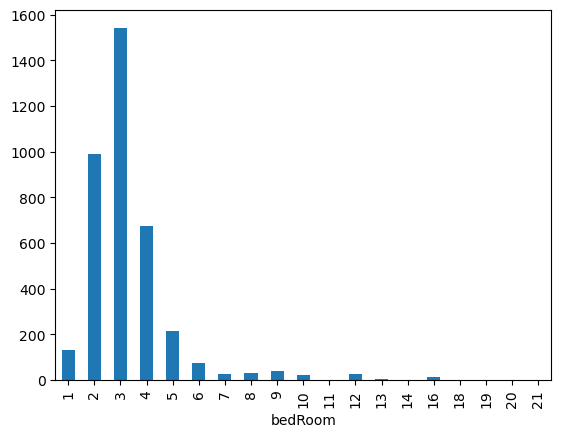

In [46]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

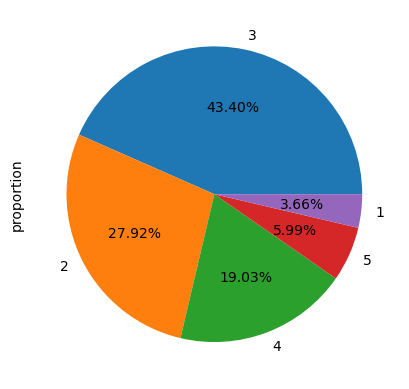

In [47]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# 7.bathroom

In [48]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

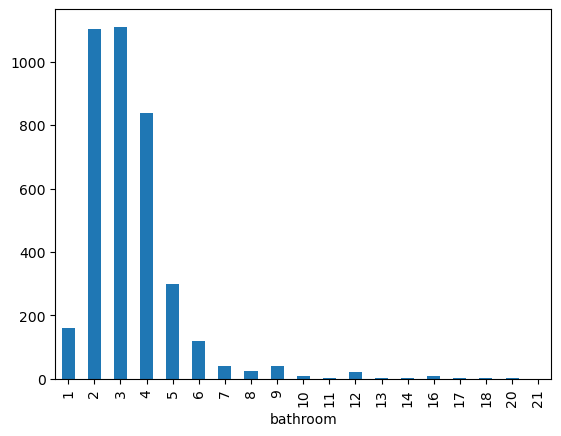

In [49]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

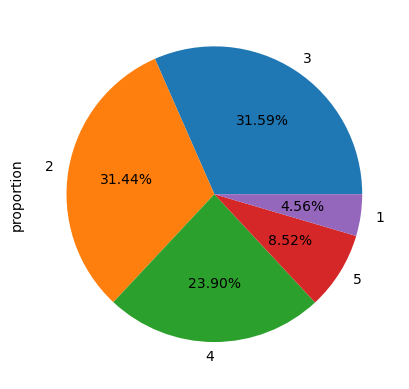

In [51]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# 8.balcony

In [52]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

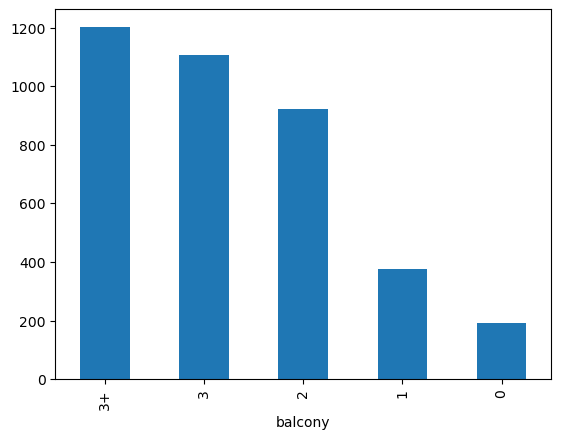

In [53]:

df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

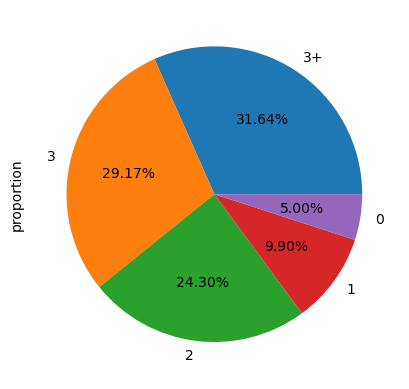

In [54]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [55]:
df.iloc[:,10:].head()

,balcony,address,floorNum,facing,agePossession,description,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,3,"245, Sector 85 Gurgaon, Gurgaon, Haryana",21.0,South,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,"['Green Area4.5 out of 5', 'Construction4.5 ou...",1640.0,NaN,NaN,0,0,0,1,0,0,67
1,3,"Sector 113 Gurgaon , Gurgaon, Haryana",3.0,North,New Property,La vida by tata housing is one of the most pop...,NaN,2690.0,2599.0,2450.0,1,1,0,0,0,0,174
2,3,"Sector 76, Delhi Gurgaon Expressway, Sector 76...",8.0,NaN,Undefined,Multistorey apartment is available for sale. I...,NaN,NaN,2937.0,1762.0,0,0,0,0,0,0,0
3,3,"B-505, Sector 43 Gurgaon, Gurgaon, Haryana",5.0,East,Old Property,Residential apartment for sell.Located in sect...,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",1850.0,NaN,NaN,1,0,0,0,0,0,0
4,2,"Sector 69 Gurgaon, Gurgaon, Haryana",8.0,East,Relatively New,A well maintained 3 bhk flat available on sale...,"['Green Area5 out of 5', 'Construction4 out of...",1578.0,NaN,NaN,0,0,0,1,0,2,94


In [57]:
df.columns

Index(['property_name', 'property_type', 'society', 'sector', 'price',
       'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom',
       'balcony', 'address', 'floorNum', 'facing', 'agePossession',
       'description', 'rating', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

# 9.floorNum

In [58]:
df['floorNum'].isnull().sum()

np.int64(19)

In [59]:
df['floorNum'].describe()

count    3780.000000
mean        6.810053
std         6.023233
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

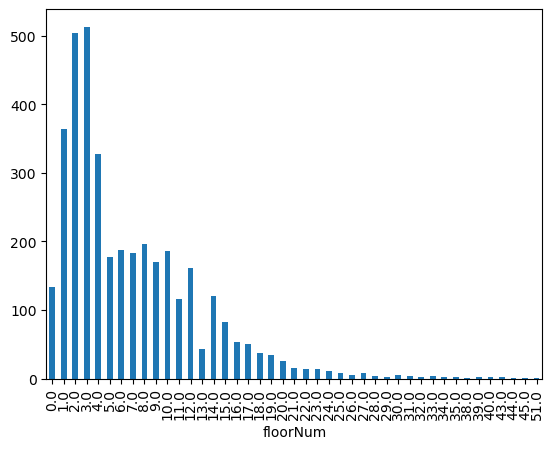

In [60]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

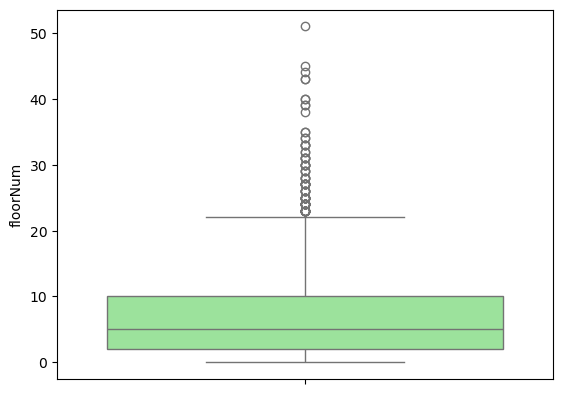

In [61]:
sns.boxplot(df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

# 10.facing

In [62]:
df['facing'].isnull().sum()

np.int64(1102)

In [63]:
df['facing'].fillna('NA',inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_736\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [64]:
df['facing'].value_counts()

facing
NA            1102
East           641
North-East     639
North          398
West           255
South          233
North-West     200
South-East     174
South-West     157
Name: count, dtype: int64

# 11.agePossession

In [65]:
df['agePossession'].isnull().sum()

np.int64(0)

In [66]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           625
Moderately Old         575
Undefined              331
Old Property           310
Under Construction     282
Name: count, dtype: int64

# 12.areas

In [67]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1885)

In [68]:
df['super_built_up_area'].describe()

count     1914.000000
mean      1922.322649
std        766.809367
min         89.000000
25%       1457.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

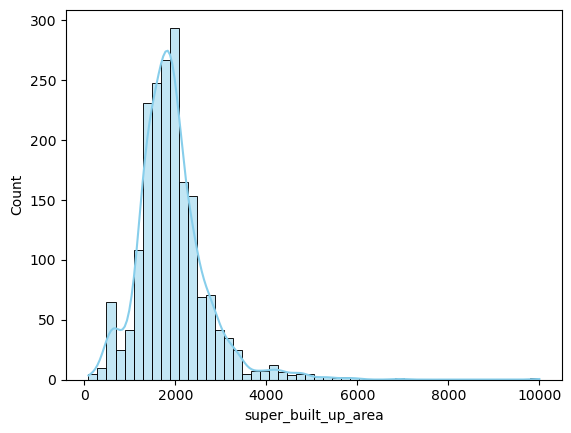

In [69]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

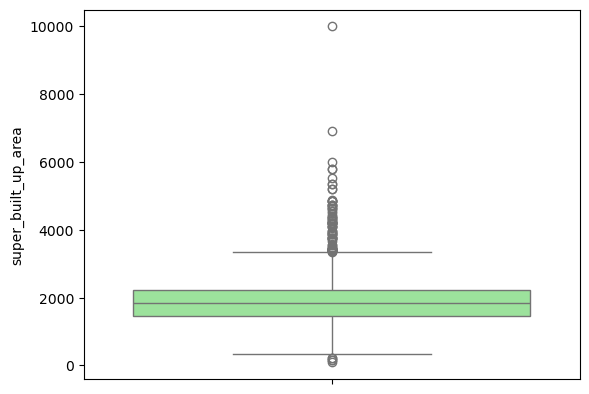

In [70]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [71]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(2068)

In [72]:
df['built_up_area'].describe()

count      1731.000000
mean       2361.172368
std       17729.821588
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2399.500000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

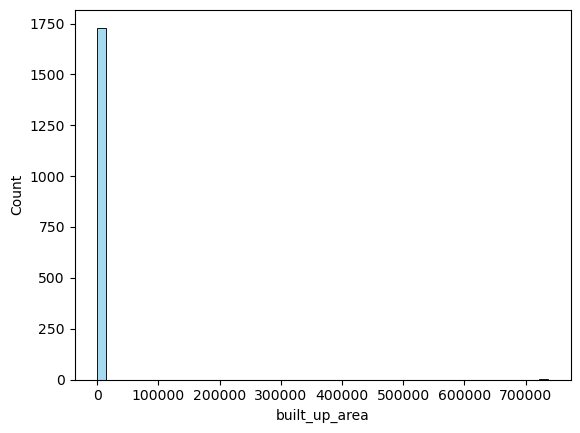

In [73]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

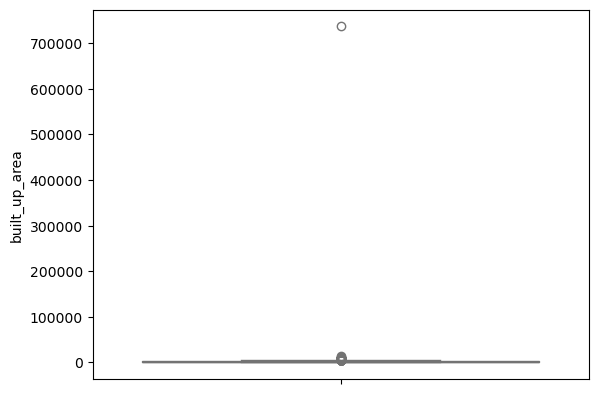

In [74]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.
- The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [75]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1857)

In [76]:
df['carpet_area'].describe()

count      1942.000000
mean       2484.217682
std       22386.751384
min          15.000000
25%         824.000000
50%        1292.000000
75%        1784.750000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

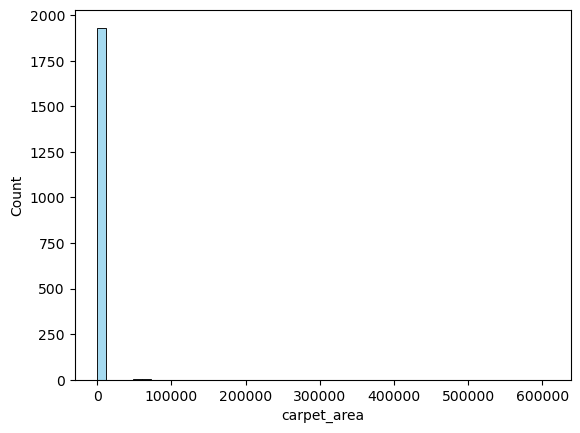

In [77]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

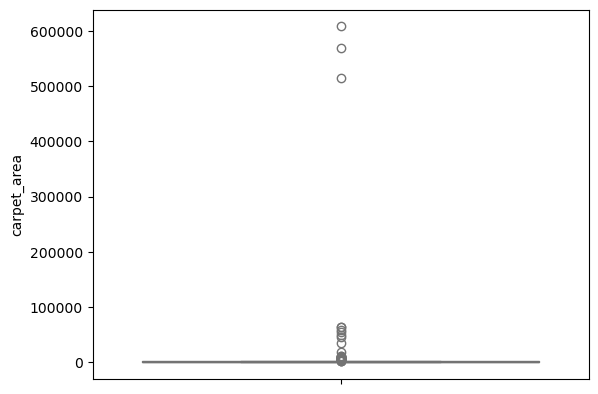

In [78]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [79]:
df.iloc[:,16:]

,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,"['Green Area4.5 out of 5', 'Construction4.5 ou...",1640.0,NaN,NaN,0,0,0,1,0,0,67
1,NaN,2690.0,2599.0,2450.0,1,1,0,0,0,0,174
2,NaN,NaN,2937.0,1762.0,0,0,0,0,0,0,0
3,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",1850.0,NaN,NaN,1,0,0,0,0,0,0
4,"['Green Area5 out of 5', 'Construction4 out of...",1578.0,NaN,NaN,0,0,0,1,0,2,94
...,...,...,...,...,...,...,...,...,...,...,...
3798,"['Green Area4 out of 5', 'Construction4 out of...",1910.0,1895.0,1800.0,0,0,0,0,1,2,49
3799,NaN,1385.0,940.0,845.0,0,0,0,0,0,2,21
3800,"['Environment4 out of 5', 'Lifestyle4 out of 5...",NaN,1845.0,1350.0,0,0,0,0,0,0,0
3801,"['Green Area5 out of 5', 'Construction4 out of...",2010.0,NaN,NaN,0,0,0,0,0,0,125


# 13.additional rooms

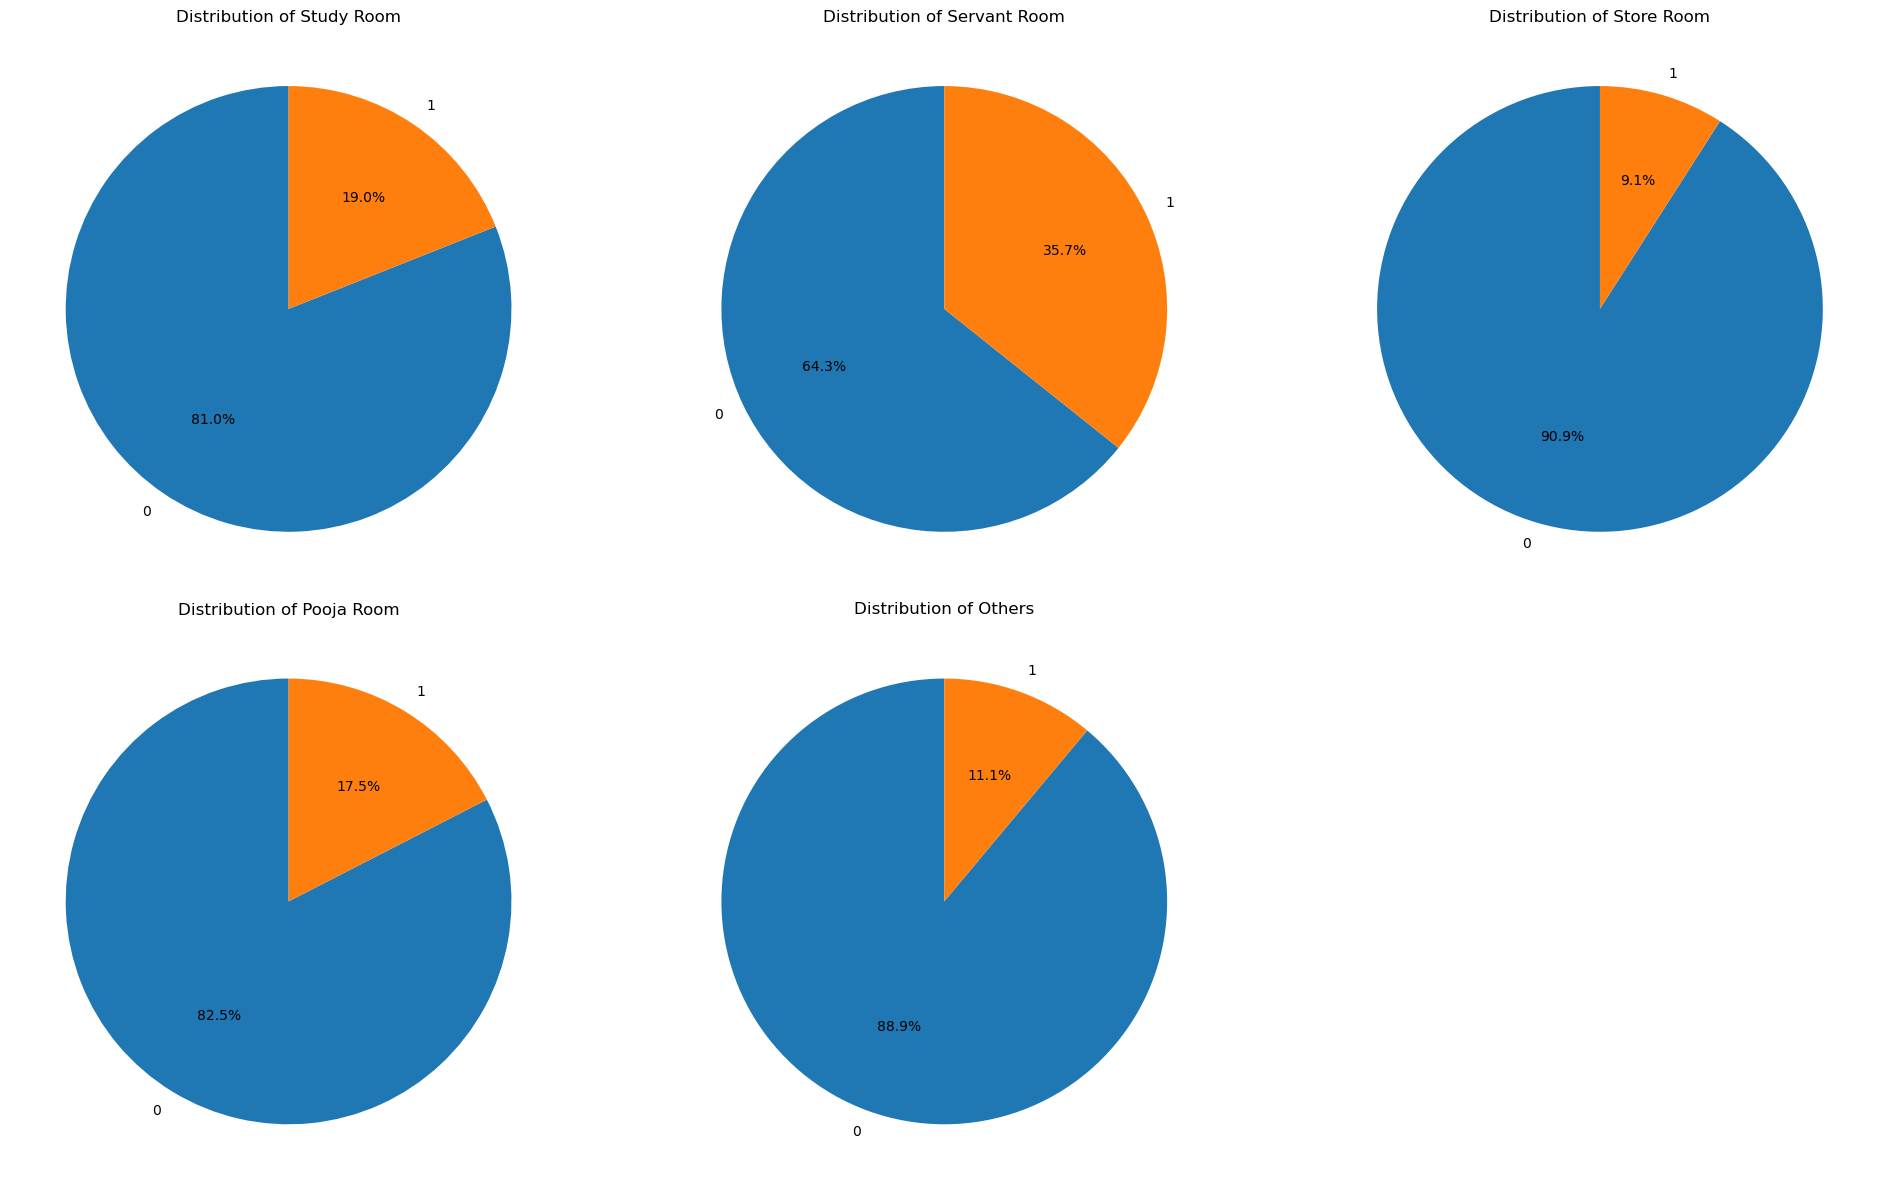

In [80]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# 14.furnishing_type

In [81]:
df['furnishing_type'].value_counts()

furnishing_type
0    2530
2    1057
1     212
Name: count, dtype: int64

<Axes: ylabel='count'>

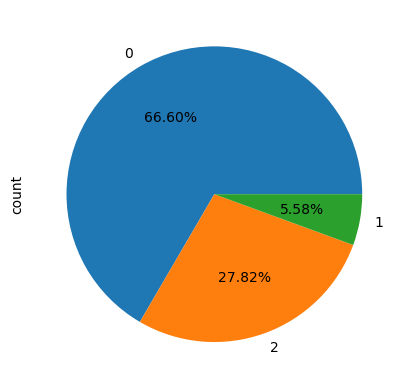

In [82]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

# 15.luxury score

In [83]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [84]:
df['luxury_score'].describe()

count    3799.000000
mean       70.959726
std        52.848156
min         0.000000
25%        31.000000
50%        58.000000
75%       109.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

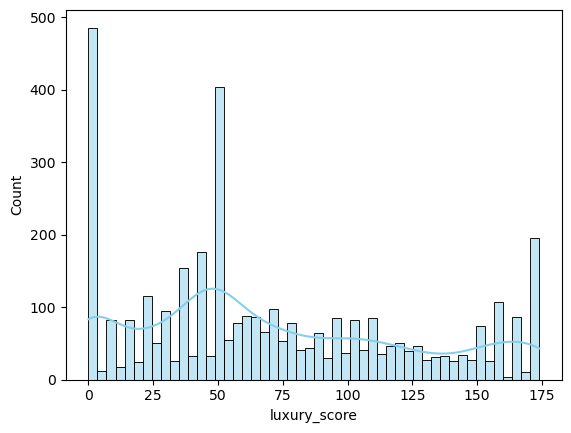

In [85]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

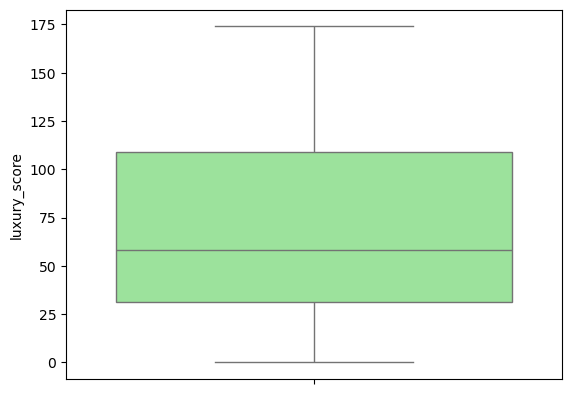

In [86]:
sns.boxplot(df['luxury_score'], color='lightgreen')

- The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

- The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.